# TalentCLEF Task B: Job Title-Based Skill Prediction
## Phase 0 (Data Exploration) & Phase 1 (All Experiment Groups)

**39 experiments** across 9 groups, tracked with Weights & Biases.

| Group | Description | Runs |
|-------|------------|------|
| 1 | BM25 Baselines | 4 |
| 2 | Bi-Encoder Raw | 3 |
| 3 | Bi-Encoder + Augmentation | 3 |
| 4 | Cross-Encoder Full Raw | 4 |
| 5 | Cross-Encoder Full + Augmentation | 4 |
| 6 | Rerank (Bi-Encoder → Cross-Encoder) | 8 |
| 7 | Rerank (BM25 → Cross-Encoder) | 8 |
| 8 | Fusion (BM25 + Bi-Encoder) | 3 |
| 9 | Fusion + Rerank | 2 |

# Download libraries, Connect to Google Drive and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Portofolios/Protofolio_2026/Job-Title-Based-Skill-Prediction-TalentClef-2025

/content/drive/MyDrive/Portofolios/Protofolio_2026/Job-Title-Based-Skill-Prediction-TalentClef-2025


In [ ]:
# ============================================================
# Install dependencies
# ============================================================
!pip install -q rank_bm25 sentence-transformers transformers torch
!pip install -q openai anthropic cohere voyageai
!pip install -q wandb pandas numpy tqdm matplotlib seaborn
!pip install -q FlagEmbedding  # for BGE reranker
!pip install -q accelerate bitsandbytes  # for large model loading

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 129.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 48.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Imports
# ============================================================
import os
import json
import ast
import time
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML / Retrieval
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import torch

# APIs
import openai
import anthropic
import cohere
import voyageai

# Tracking
import wandb

### Read Keys from `config_api.py`

This file contains all API keys, model strings, and paths. **Never commit it to git.**

In [ ]:
# ============================================================
# Load configuration from config_api.py
# ============================================================
# If config_api.py is not in the current directory, upload it first:
# from google.colab import files
# files.upload()

import config_api

# Build CONFIG dict from the config file
CONFIG = {
    # API Keys
    "OPENAI_API_KEY": config_api.OPENAI_API_KEY,
    "ANTHROPIC_API_KEY": config_api.ANTHROPIC_API_KEY,
    "COHERE_API_KEY": config_api.COHERE_API_KEY,
    "VOYAGE_API_KEY": config_api.VOYAGE_API_KEY,
    "WANDB_API_KEY": config_api.WANDB_API_KEY,
    "TOGETHER_API_KEY": config_api.TOGETHER_API_KEY,

    # LLM model strings
    "LLM_QWEN": config_api.LLM_QWEN,
    "LLM_OPUS": config_api.LLM_OPUS,
    "LLM_GPT": config_api.LLM_GPT,
    "QWEN_BASE_URL": config_api.QWEN_BASE_URL,

    # Bi-encoder model strings
    "BIENC_QWEN": config_api.BIENC_QWEN,
    "BIENC_BGE": config_api.BIENC_BGE,
    "BIENC_OPENAI": config_api.BIENC_OPENAI,

    # Cross-encoder model strings
    "CROSSENC_BGE": config_api.CROSSENC_BGE,
    "CROSSENC_QWEN": config_api.CROSSENC_QWEN,
    "CROSSENC_VOYAGE": config_api.CROSSENC_VOYAGE,
    "CROSSENC_COHERE": config_api.CROSSENC_COHERE,

    # Experiment settings
    "RERANK_TOP_K": config_api.RERANK_TOP_K + 150, #250
    "RRF_K": config_api.RRF_K,
    "WANDB_PROJECT": config_api.WANDB_PROJECT + "_2",

    # Paths
    "DATA_DIR": config_api.DATA_DIR,
    "OUTPUT_DIR": config_api.OUTPUT_DIR,
    "DESC_DIR": config_api.DESC_DIR,
}

# Set environment variables for API clients
os.environ["OPENAI_API_KEY"] = CONFIG["OPENAI_API_KEY"]
os.environ["ANTHROPIC_API_KEY"] = CONFIG["ANTHROPIC_API_KEY"]
os.environ["COHERE_API_KEY"] = CONFIG["COHERE_API_KEY"]
os.environ["VOYAGE_API_KEY"] = CONFIG["VOYAGE_API_KEY"]

# Create output directories
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
os.makedirs(CONFIG["DESC_DIR"], exist_ok=True)

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory  / 1e9:.1f} GB")

# Verify keys are set
for key_name in ["OPENAI_API_KEY", "ANTHROPIC_API_KEY", "COHERE_API_KEY", "VOYAGE_API_KEY", "WANDB_API_KEY"]:
    status = "✓ Set" if CONFIG[key_name] else "✗ Missing"
    print(f"  {key_name}: {status}")

Device: cuda
GPU: NVIDIA H100 80GB HBM3
Memory: 85.0 GB
  OPENAI_API_KEY: ✓ Set
  ANTHROPIC_API_KEY: ✓ Set
  COHERE_API_KEY: ✓ Set
  VOYAGE_API_KEY: ✓ Set
  WANDB_API_KEY: ✓ Set


In [ ]:
# ============================================================
# W&B Login
# ============================================================
if CONFIG["WANDB_API_KEY"]:
    wandb.login(key=CONFIG["WANDB_API_KEY"])
    print("W&B logged in successfully")
else:
    print("WARNING: No W&B API key set. Runs will be logged locally only.")
    os.environ["WANDB_MODE"] = "offline"

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: venetispall to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B logged in successfully


---
# Phase 0: Data Exploration

### Load Training Data

In [ ]:
# ============================================================
# Load training data
# ============================================================
train_path = os.path.join(CONFIG["DATA_DIR"], "training")

# Job-to-skill relations
job2skill = pd.read_csv(
    os.path.join(train_path, "job2skill.tsv"),
    sep="\t",
    names=["job_id", "skill_id", "rel_type"]
)

# Job ID to terms mapping
with open(os.path.join(train_path, "jobid2terms.json"), 'r') as f:
    jobid2terms = json.load(f)

# Skill ID to terms mapping
with open(os.path.join(train_path, "skillid2terms.json"), 'r') as f:
    skillid2terms = json.load(f)

# Merge terms into the dataframe
job2skill["job_terms"] = job2skill["job_id"].map(jobid2terms)
job2skill["skill_terms"] = job2skill["skill_id"].map(skillid2terms)

print(f"Training data loaded: {len(job2skill)} job-skill pairs")
print(f"Unique jobs: {job2skill['job_id'].nunique()}")
print(f"Unique skills: {job2skill['skill_id'].nunique()}")
print(f"\nRelation type distribution:")
print(job2skill['rel_type'].value_counts())
print(f"\nAvg skills per job: {job2skill.groupby('job_id')['skill_id'].count().mean():.1f}")
print(f"\nSample:")
job2skill.head(3)

Training data loaded: 114699 job-skill pairs
Unique jobs: 3011
Unique skills: 13224

Relation type distribution:
rel_type
essential    62480
optional     52219
Name: count, dtype: int64

Avg skills per job: 38.1

Sample:


,job_id,skill_id,rel_type,job_terms,skill_terms
0,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/93a68dcb-3dc6...,essential,"[technical director, technical and operations ...","[promote health and safety, promote importance..."
1,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/05bc7677-5a64...,essential,"[technical director, technical and operations ...","[organise rehearsals, organise rehearsal, orga..."
2,http://data.europa.eu/esco/occupation/00030d09...,http://data.europa.eu/esco/skill/860be36a-d19b...,essential,"[technical director, technical and operations ...",[negotiate health and safety issues with third...


### Load Dev Data

In [ ]:
# ============================================================
# Load dev/validation data
# ============================================================
dev_path = os.path.join(CONFIG["DATA_DIR"], "validation")

# Queries
dev_queries = pd.read_csv(os.path.join(dev_path, "queries"), sep="\t")
print(f"Dev queries: {len(dev_queries)}")
print(f"Columns: {dev_queries.columns.tolist()}")

# Corpus elements
dev_corpus = pd.read_csv(os.path.join(dev_path, "corpus_elements"), sep="\t")
print(f"\nDev corpus: {len(dev_corpus)} skills")
print(f"Columns: {dev_corpus.columns.tolist()}")

# QRels (ground truth)
dev_qrels = pd.read_csv(
    os.path.join(dev_path, "qrels.tsv"),
    sep="\t",
    names=["q_id", "iter", "c_id", "relevance"]
)
print(f"\nDev qrels: {len(dev_qrels)} entries")
print(f"Relevance distribution:\n{dev_qrels['relevance'].value_counts()}")

print(f"\nSample queries:")
print(dev_queries.head())
print(f"\nSample corpus:")
print(dev_corpus.head())
print(f"\nSample qrels:")
print(dev_qrels.head())

Dev queries: 304
Columns: ['q_id', 'jobtitle']

Dev corpus: 1439 skills
Columns: ['c_id', 'esco_uri', 'skill_aliases']

Dev qrels: 25888 entries
Relevance distribution:
relevance
1    25888
Name: count, dtype: int64

Sample queries:
          q_id                      jobtitle
0  dev_qb_jt_1  corporate governance analyst
1  dev_qb_jt_2    logistics business analyst
2  dev_qb_jt_3   operations planning analyst
3  dev_qb_jt_4      real estate data analyst
4  dev_qb_jt_5           security analyst ii

Sample corpus:
          c_id                                           esco_uri  \
0  dev_cb_sk_1  http://data.europa.eu/esco/skill/1c460d2d-90c6...   
1  dev_cb_sk_2  http://data.europa.eu/esco/skill/301a6581-e983...   
2  dev_cb_sk_3  http://data.europa.eu/esco/skill/a4881e54-6055...   
3  dev_cb_sk_4  http://data.europa.eu/esco/skill/efda73b4-5212...   
4  dev_cb_sk_5  http://data.europa.eu/esco/skill/22a173f5-868c...   

                                       skill_aliases  
0  ['pricin

### Load Test Data

In [ ]:
# ============================================================
# Load test data
# ============================================================
test_path = os.path.join(CONFIG["DATA_DIR"], "test")

test_queries = pd.read_csv(os.path.join(test_path, "queries"), sep="\t")
test_corpus = pd.read_csv(os.path.join(test_path, "corpus_elements"), sep="\t")

print(f"Test queries: {len(test_queries)}")
print(f"Test corpus: {len(test_corpus)} skills")
print(f"\nSample test queries:")
print(test_queries.head())

Test queries: 1520
Test corpus: 1986 skills

Sample test queries:
       q_id                            jobtitle
0  15ec5e80                  Qdoba Mexican Eats
1  a0d97669                         Hairstylist
2  4b3976f7                       Digital Logic
3  a3bc11cc  Interstate/Local Moving Contractor
4  e12ee1fd                      Press Operator


### Key Statistics

In [ ]:
# ============================================================
# Compute key statistics
# ============================================================
print("=" * 60)
print("KEY STATISTICS")
print("=" * 60)

# Training stats
n_train_jobs = job2skill['job_id'].nunique()
n_train_skills = job2skill['skill_id'].nunique()
skills_per_job = job2skill.groupby('job_id')['skill_id'].count()
essential_per_job = job2skill[job2skill.rel_type == 'essential'].groupby('job_id')['skill_id'].count()
optional_per_job = job2skill[job2skill.rel_type == 'optional'].groupby('job_id')['skill_id'].count()

print(f"\n--- Training Set ---")
print(f"Unique jobs: {n_train_jobs}")
print(f"Unique skills: {n_train_skills}")
print(f"Total pairs: {len(job2skill)}")
print(f"Skills per job: mean={skills_per_job.mean():.1f}, median={skills_per_job.median():.0f}, "
      f"min={skills_per_job.min()}, max={skills_per_job.max()}")
print(f"Essential per job: mean={essential_per_job.mean():.1f}")
print(f"Optional per job: mean={optional_per_job.mean():.1f}")
print(f"Job aliases per job: mean={np.mean([len(v) for v in jobid2terms.values()]):.1f}")
print(f"Skill aliases per skill: mean={np.mean([len(v) for v in skillid2terms.values()]):.1f}")

# Dev stats
n_dev_queries = len(dev_queries)
n_dev_corpus = len(dev_corpus)
relevant_per_query = dev_qrels[dev_qrels.relevance == 1].groupby('q_id')['c_id'].count()

print(f"\n--- Dev Set ---")
print(f"Queries: {n_dev_queries}")
print(f"Corpus skills: {n_dev_corpus}")
print(f"Relevant skills per query: mean={relevant_per_query.mean():.1f}, "
      f"median={relevant_per_query.median():.0f}, min={relevant_per_query.min()}, "
      f"max={relevant_per_query.max()}")

# Test stats
print(f"\n--- Test Set ---")
print(f"Queries: {len(test_queries)}")
print(f"Corpus skills: {len(test_corpus)}")

# Overlap analysis
dev_corpus_uris = set()
for _, row in dev_corpus.iterrows():
    if pd.notna(row.get('esco_uri', None)):
        dev_corpus_uris.add(row['esco_uri'])

train_skill_uris = set(job2skill['skill_id'].unique())

overlap = dev_corpus_uris.intersection(train_skill_uris)
print(f"\n--- Overlap Analysis ---")
print(f"Dev corpus ESCO URIs: {len(dev_corpus_uris)}")
print(f"Training skill URIs: {len(train_skill_uris)}")
print(f"Overlap (dev skills seen in training): {len(overlap)} ({100*len(overlap)/max(len(dev_corpus_uris),1):.1f}%)")

# Check if dev job titles appear in training
train_job_titles = set()
for terms in jobid2terms.values():
    for t in terms:
        train_job_titles.add(t.lower().strip())

dev_jobs_in_train = 0
for _, row in dev_queries.iterrows():
    if row['jobtitle'].lower().strip() in train_job_titles:
        dev_jobs_in_train += 1
print(f"Dev job titles found in training aliases: {dev_jobs_in_train}/{n_dev_queries} "
      f"({100*dev_jobs_in_train/n_dev_queries:.1f}%)")

KEY STATISTICS

--- Training Set ---
Unique jobs: 3011
Unique skills: 13224
Total pairs: 114699
Skills per job: mean=38.1, median=36, min=7, max=69
Essential per job: mean=20.8
Optional per job: mean=18.4
Job aliases per job: mean=11.0
Skill aliases per skill: mean=7.2

--- Dev Set ---
Queries: 304
Corpus skills: 1439
Relevant skills per query: mean=85.2, median=82, min=21, max=179

--- Test Set ---
Queries: 1520
Corpus skills: 1986

--- Overlap Analysis ---
Dev corpus ESCO URIs: 1439
Training skill URIs: 13224
Overlap (dev skills seen in training): 1379 (95.8%)
Dev job titles found in training aliases: 12/304 (3.9%)


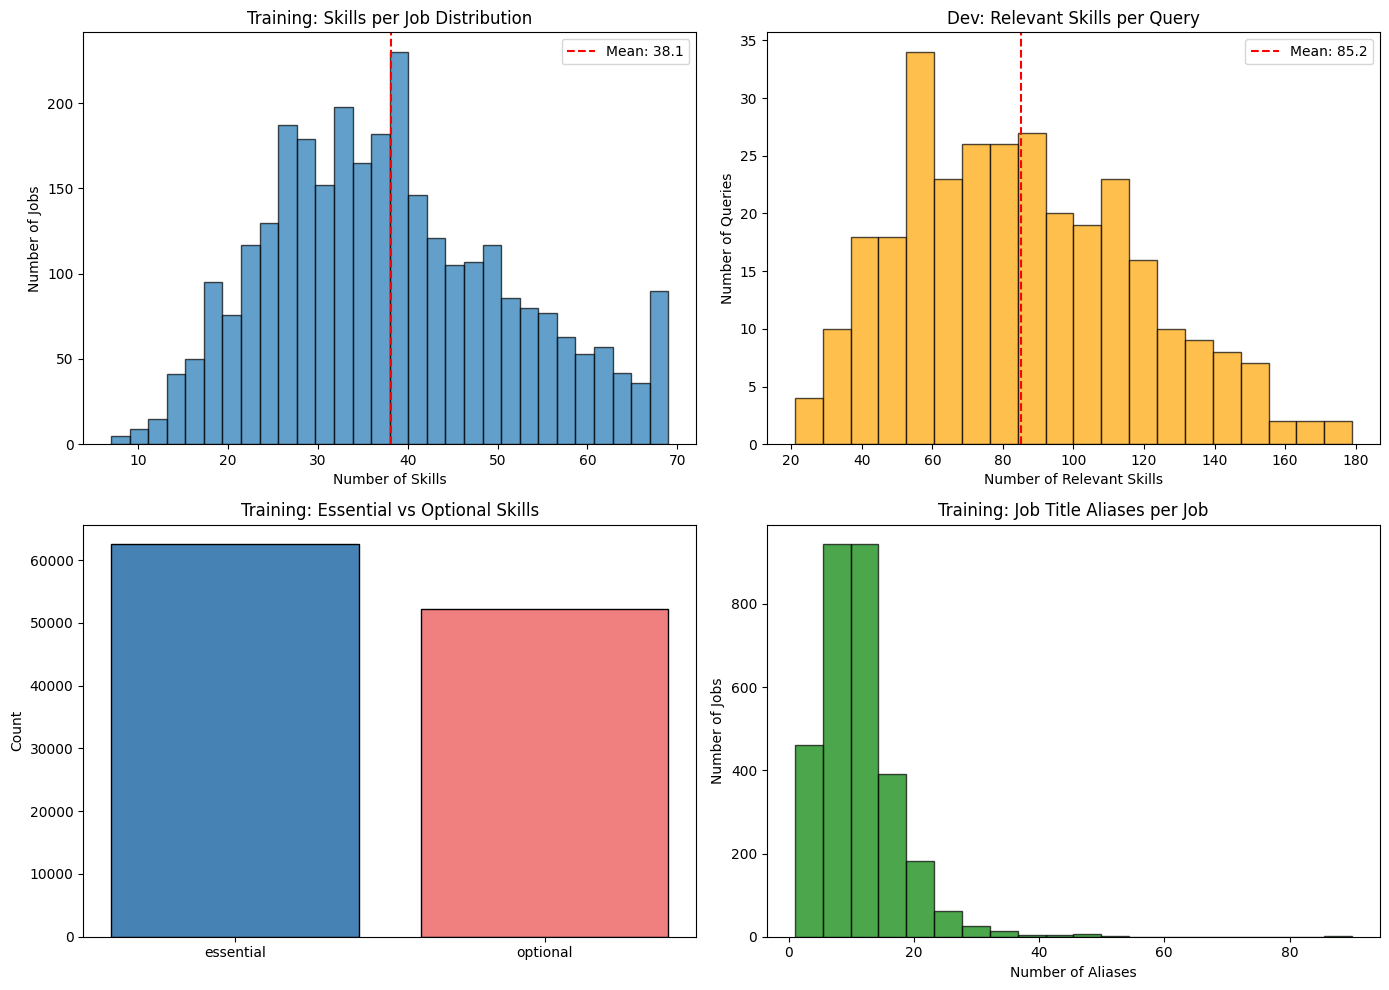

In [ ]:
# ============================================================
# Visualizations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Skills per job distribution
axes[0, 0].hist(skills_per_job, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Skills')
axes[0, 0].set_ylabel('Number of Jobs')
axes[0, 0].set_title('Training: Skills per Job Distribution')
axes[0, 0].axvline(skills_per_job.mean(), color='red', linestyle='--', label=f'Mean: {skills_per_job.mean():.1f}')
axes[0, 0].legend()

# 2. Relevant skills per query in dev
axes[0, 1].hist(relevant_per_query, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Number of Relevant Skills')
axes[0, 1].set_ylabel('Number of Queries')
axes[0, 1].set_title('Dev: Relevant Skills per Query')
axes[0, 1].axvline(relevant_per_query.mean(), color='red', linestyle='--', label=f'Mean: {relevant_per_query.mean():.1f}')
axes[0, 1].legend()

# 3. Essential vs Optional
rel_counts = job2skill['rel_type'].value_counts()
axes[1, 0].bar(rel_counts.index, rel_counts.values, color=['steelblue', 'lightcoral'], edgecolor='black')
axes[1, 0].set_title('Training: Essential vs Optional Skills')
axes[1, 0].set_ylabel('Count')

# 4. Job aliases distribution
alias_counts = [len(v) for v in jobid2terms.values()]
axes[1, 1].hist(alias_counts, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Number of Aliases')
axes[1, 1].set_ylabel('Number of Jobs')
axes[1, 1].set_title('Training: Job Title Aliases per Job')

plt.tight_layout()
plt.show()

---
# Evaluation & Utility Functions

In [ ]:
# ============================================================
# Data preparation helpers
# ============================================================

def prepare_dev_data():
    """Prepare dev data into standardized format for experiments."""
    queries = dict(zip(dev_queries['q_id'], dev_queries['jobtitle']))

    corpus = {}
    for _, row in dev_corpus.iterrows():
        aliases = row['skill_aliases']
        if isinstance(aliases, str):
            try:
                aliases = ast.literal_eval(aliases)
            except:
                aliases = [aliases]
        corpus[row['c_id']] = {
            "esco_uri": row.get('esco_uri', ''),
            "aliases": aliases
        }

    qrels = defaultdict(set)
    for _, row in dev_qrels.iterrows():
        if row['relevance'] == 1:
            qrels[row['q_id']].add(row['c_id'])

    return queries, corpus, dict(qrels)

def prepare_test_data():
    """Prepare test data."""
    queries = dict(zip(test_queries['q_id'], test_queries['jobtitle']))
    corpus = {}
    for _, row in test_corpus.iterrows():
        aliases = row['skill_aliases']
        if isinstance(aliases, str):
            try:
                aliases = ast.literal_eval(aliases)
            except:
                aliases = [aliases]
        corpus[row['c_id']] = {
            "esco_uri": row.get('esco_uri', ''),
            "aliases": aliases
        }
    return queries, corpus

def get_corpus_text(corpus, c_id, descriptions=None):
    """Get text representation for a corpus skill."""
    aliases = corpus[c_id]["aliases"]
    text = ", ".join(aliases) if isinstance(aliases, list) else str(aliases)
    if descriptions and c_id in descriptions:
        text = f"Skill: {text} [SEP] Description: {descriptions[c_id]}"
    return text

def get_query_text(query_title, descriptions=None, q_id=None):
    """Get text representation for a query."""
    text = query_title
    if descriptions and q_id and q_id in descriptions:
        text = f"Job: {query_title} [SEP] Description: {descriptions[q_id]}"
    return text

# Prepare dev data
dev_q, dev_c, dev_qr = prepare_dev_data()
print(f"Dev: {len(dev_q)} queries, {len(dev_c)} corpus skills, "
      f"{len(dev_qr)} queries with relevance judgments")

Dev: 304 queries, 1439 corpus skills, 304 queries with relevance judgments


In [ ]:
# ============================================================
# Evaluation metrics
# ============================================================

def compute_ap(ranked_list, relevant_set):
    """Compute Average Precision for a single query."""
    if not relevant_set:
        return 0.0
    hits = 0
    sum_precision = 0.0
    for i, doc_id in enumerate(ranked_list):
        if doc_id in relevant_set:
            hits += 1
            sum_precision += hits / (i + 1)
    return sum_precision / len(relevant_set)

def compute_rr(ranked_list, relevant_set):
    """Compute Reciprocal Rank for a single query."""
    for i, doc_id in enumerate(ranked_list):
        if doc_id in relevant_set:
            return 1.0 / (i + 1)
    return 0.0

def compute_precision_at_k(ranked_list, relevant_set, k):
    """Compute Precision@K for a single query."""
    top_k = ranked_list[:k]
    relevant_in_top_k = sum(1 for d in top_k if d in relevant_set)
    return relevant_in_top_k / k

def evaluate(run_results, qrels):
    """
    Evaluate a run against ground truth.

    Args:
        run_results: dict of {q_id: [(c_id, score), ...]} sorted by score descending
        qrels: dict of {q_id: set(relevant_c_ids)}

    Returns:
        dict with MAP, MRR, P@1, P@5, P@10 and per-query breakdowns
    """
    aps, rrs, p1s, p5s, p10s = [], [], [], [], []
    per_query = {}

    for q_id in qrels:
        if q_id not in run_results:
            ranked = []
        else:
            ranked = [c_id for c_id, _ in run_results[q_id]]

        relevant = qrels[q_id]
        ap = compute_ap(ranked, relevant)
        rr = compute_rr(ranked, relevant)
        p1 = compute_precision_at_k(ranked, relevant, 1)
        p5 = compute_precision_at_k(ranked, relevant, 5)
        p10 = compute_precision_at_k(ranked, relevant, 10)

        aps.append(ap)
        rrs.append(rr)
        p1s.append(p1)
        p5s.append(p5)
        p10s.append(p10)
        per_query[q_id] = {"AP": ap, "RR": rr, "P@1": p1, "P@5": p5, "P@10": p10}

    metrics = {
        "MAP": np.mean(aps),
        "MRR": np.mean(rrs),
        "P@1": np.mean(p1s),
        "P@5": np.mean(p5s),
        "P@10": np.mean(p10s),
    }
    return metrics, per_query

print("Evaluation functions ready")

Evaluation functions ready


In [ ]:
# ============================================================
# W&B logging and TREC file utilities
# ============================================================

ALL_RESULTS = []  # Accumulator for summary table

def log_experiment(run_name, group, metrics, config_extra=None, run_results=None):
    """Log an experiment to W&B and the local results accumulator."""
    config = {
        "run_name": run_name,
        "group": group,
    }
    if config_extra:
        config.update(config_extra)

    # Log to W&B
    run = wandb.init(
        project=CONFIG["WANDB_PROJECT"],
        name=run_name,
        group=group,
        config=config,
        reinit=True,
    )
    wandb.log(metrics)

    # Save TREC run file as artifact
    if run_results:
        trec_path = save_trec_run(run_results, run_name)
        artifact = wandb.Artifact(f"trec-{run_name}", type="predictions")
        artifact.add_file(trec_path)
        wandb.log_artifact(artifact)

    wandb.finish()

    # Accumulate locally
    result_row = {"run_name": run_name, "group": group, **metrics}
    ALL_RESULTS.append(result_row)
    print(f"  [{run_name}] MAP={metrics['MAP']:.4f}  MRR={metrics['MRR']:.4f}  "
          f"P@1={metrics['P@1']:.4f}  P@5={metrics['P@5']:.4f}  P@10={metrics['P@10']:.4f}")

def save_trec_run(run_results, run_name):
    """Save results in TREC run file format."""
    path = os.path.join(CONFIG["OUTPUT_DIR"], f"{run_name}.trec")
    with open(path, 'w') as f:
        for q_id in run_results:
            for rank, (c_id, score) in enumerate(run_results[q_id]):
                f.write(f"{q_id}\tQ0\t{c_id}\t{rank+1}\t{score:.6f}\t{run_name}\n")
    return path

def results_to_ranked(scores_dict):
    """
    Convert {q_id: {c_id: score}} to {q_id: [(c_id, score), ...]} sorted descending.
    """
    run_results = {}
    for q_id, skill_scores in scores_dict.items():
        sorted_skills = sorted(skill_scores.items(), key=lambda x: x[1], reverse=True)
        run_results[q_id] = sorted_skills
    return run_results

def load_trec_results(run_name):
    """Load results from saved TREC file."""
    path = os.path.join(CONFIG["OUTPUT_DIR"], f"{run_name}.trec")
    if not os.path.exists(path):
        return None
    results = defaultdict(list)
    with open(path) as f:
        for line in f:
            parts = line.strip().split("\t")
            q_id, _, c_id, rank, score, _ = parts
            results[q_id].append((c_id, float(score)))
    return {q_id: sorted(pairs, key=lambda x: x[1], reverse=True) for q_id, pairs in results.items()}

print("Logging utilities ready")

Logging utilities ready


# Phase 1: Experiments (Zero-Shot, No Fine-Tuning)

39 runs across 9 groups. All results tracked in W&B project: `talentclef-task-b`.

**Execution order:**
- **Wave 1:** Groups 1–2 (BM25 + Bi-Encoder baselines)
- **Wave 2:** LLM descriptions + Groups 1 aug, 3 (augmented retrieval)
- **Wave 3:** Groups 4–7 (cross-encoder full scoring + reranking)
- **Wave 4:** Groups 8–9 (fusion + fusion with reranking)

---
# Group 1: BM25 Baselines

Index corpus skills (concatenated aliases) as documents.
Query with job title strings. Augmented variants expand queries with LLM descriptions.

In [ ]:
# ============================================================
# BM25 retrieval function
# ============================================================

def run_bm25(queries, corpus, query_descriptions=None):
    """
    Run BM25 retrieval.

    Args:
        queries: {q_id: jobtitle}
        corpus: {c_id: {"aliases": [...], ...}}
        query_descriptions: {q_id: description_text} or None

    Returns:
        {q_id: {c_id: score}}
    """
    c_ids = list(corpus.keys())
    corpus_texts = []
    for c_id in c_ids:
        aliases = corpus[c_id]["aliases"]
        text = " ".join(aliases) if isinstance(aliases, list) else str(aliases)
        corpus_texts.append(text.lower().split())

    bm25 = BM25Okapi(corpus_texts)

    scores = {}
    for q_id, jobtitle in tqdm(queries.items(), desc="BM25"):
        query_text = jobtitle
        if query_descriptions and q_id in query_descriptions:
            query_text = f"{jobtitle} {query_descriptions[q_id]}"

        tokenized_query = query_text.lower().split()
        doc_scores = bm25.get_scores(tokenized_query)

        scores[q_id] = {c_ids[i]: float(doc_scores[i]) for i in range(len(c_ids))}

    return scores

print("BM25 function ready")

BM25 function ready


In [ ]:
# ============================================================
# Group 1, Run 1: BM25 Raw
# ============================================================
print("\n" + "="*60)
print("Running: bm25_raw")
print("="*60)

t0 = time.time()
bm25_raw_scores = run_bm25(dev_q, dev_c)
bm25_raw_results = results_to_ranked(bm25_raw_scores)
elapsed = time.time() - t0

metrics, per_query = evaluate(bm25_raw_results, dev_qr)
metrics["inference_time_seconds"] = elapsed

log_experiment(
    run_name="bm25_raw",
    group="group_1_bm25",
    metrics=metrics,
    config_extra={"retrieval_method": "bm25", "augmentation_llm": "none"},
    run_results=bm25_raw_results,
)


Running: bm25_raw


BM25:   0%|          | 0/304 [00:00<?, ?it/s]

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Detected [anthropic, cohere, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.10919
MRR,0.57633
P@1,0.43092
P@10,0.275
P@5,0.33618


  [bm25_raw] MAP=0.1092  MRR=0.5763  P@1=0.4309  P@5=0.3362  P@10=0.2750


---
## LLM Description Generation

Generate concise job descriptions for all job titles using 3 LLMs.
These descriptions are used for query augmentation in subsequent experiments.

In [ ]:
# ============================================================
# Description generation prompt
# ============================================================
#EXPERIMENT 1
DESCRIPTION_PROMPT = """You are an expert HR assistant specialized in writing job descriptions.
Generate a highly concise, professional, and factual job description based ONLY on the provided job title.
Focus on typical key responsibilities. Crucially, explicitly list 2-3 common, essential skills
associated with the role within the description. Do not add information not directly implied by the
job title. The description must be brief, ideally 2-3 sentences maximum. Output only the description
text, without any preamble or introductory phrases."""

# Problem 1: Only 2-3 skills, but queries average 85.2 relevant skills.
#The prompt asks for 2-3 skills, which covers maybe 3% of what's relevant. More skill terms = more lexical and semantic overlap with the corpus.
# Problem 2: No alignment with ESCO vocabulary. The corpus uses ESCO skill aliases like "pricing strategies", "tuning procedures", "iconography methods".
#If the LLM generates natural descriptions using different vocabulary, it may not match well.

#Problem 3: One-size-fits-all. BM25 needs keyword-rich descriptions, while bi-encoders need semantically precise ones. Different prompts might work better for different methods.
#For cost reasons, we will continue to use a prompt that tries to tackle both

#EXPERIMENT 2 (new description and increased reranking topk from 100 to 250)
DESCRIPTION_PROMPT = """You are an expert HR assistant specialized in writing job descriptions and mapping roles to standardized occupational taxonomies.

For this job title, provide:
1. A one-sentence role summary
2. 5-6 essential professional skills using standardized ESCO (European Skills, Competences, Qualifications and Occupations) terminology. Examples of ESCO skill phrasing: "apply communication techniques", "manage budgets", "use database management systems", "develop professional network", "ensure compliance with regulations", "analyse financial risk"
3. 2-3 related or synonymous job titles as they would appear in a formal occupational taxonomy
Output only the above, no preamble or extra commentary."""

def generate_descriptions_openai(job_titles, model=None):
    """Generate descriptions using OpenAI API."""
    model = model or CONFIG["LLM_GPT"]
    client = openai.OpenAI()
    descriptions = {}
    for q_id, title in tqdm(job_titles.items(), desc=f"OpenAI ({model})"):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": DESCRIPTION_PROMPT},
                    {"role": "user", "content": f"Job title: {title}"}
                ],
                max_completion_tokens=200,
                temperature=0.3,
            )
            descriptions[q_id] = response.choices[0].message.content.strip()
        except Exception as e:
            print(f"  Error for {q_id} ({title}): {e}")
            descriptions[q_id] = ""
    return descriptions

def generate_descriptions_anthropic(job_titles, model=None):
    """Generate descriptions using Anthropic API."""
    model = model or CONFIG["LLM_OPUS"]
    client = anthropic.Anthropic()
    descriptions = {}
    for q_id, title in tqdm(job_titles.items(), desc=f"Claude ({model})"):
        try:
            response = client.messages.create(
                model=model,
                max_tokens=200,
                system=DESCRIPTION_PROMPT,
                messages=[
                    {"role": "user", "content": f"Job title: {title}"}
                ],
            )
            descriptions[q_id] = response.content[0].text.strip()
        except Exception as e:
            print(f"  Error for {q_id} ({title}): {e}")
            descriptions[q_id] = ""
    return descriptions

def generate_descriptions_qwen(job_titles, model=None):
    """
    Generate descriptions using Qwen via OpenAI-compatible API.
    Update QWEN_BASE_URL in config_api.py to your endpoint.
    """
    model = model or CONFIG["LLM_QWEN"]
    client = openai.OpenAI(
        base_url=CONFIG["QWEN_BASE_URL"],
        api_key=CONFIG["TOGETHER_API_KEY"],
    )
    descriptions = {}
    for q_id, title in tqdm(job_titles.items(), desc=f"Qwen ({model})"):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": DESCRIPTION_PROMPT},
                    {"role": "user", "content": f"Job title: {title}"}
                ],
                max_tokens=200,
                temperature=0.3,
            )
            descriptions[q_id] = response.choices[0].message.content.strip()
        except Exception as e:
            print(f"  Error for {q_id} ({title}): {e}")
            descriptions[q_id] = ""
    return descriptions

print("Description generation functions ready")

Description generation functions ready


In [ ]:
# ============================================================
# Generate descriptions for dev queries
# ============================================================
# Uncomment the LLMs you want to run (requires API keys)

desc_cache = {}

# --- gpt-5.4 ---
desc_cache["gpt54"] = generate_descriptions_openai(dev_q)
with open(os.path.join(CONFIG["DESC_DIR"], "dev_desc_gpt54.json"), 'w') as f:
    json.dump(desc_cache["gpt54"], f)

# --- claude-opus-4-6 ---
desc_cache["opus"] = generate_descriptions_anthropic(dev_q)
with open(os.path.join(CONFIG["DESC_DIR"], "dev_desc_opus.json"), 'w') as f:
    json.dump(desc_cache["opus"], f)

# --- Qwen3-Next-80B-A3B-Instruct ---
desc_cache["qwen3"] = generate_descriptions_qwen(dev_q)
with open(os.path.join(CONFIG["DESC_DIR"], "dev_desc_qwen3.json"), 'w') as f:
    json.dump(desc_cache["qwen3"], f)


OpenAI (gpt-5.4):   0%|          | 0/304 [00:00<?, ?it/s]

Claude (claude-opus-4-6):   0%|          | 0/304 [00:00<?, ?it/s]

Qwen (Qwen/Qwen3-Next-80B-A3B-Instruct):   0%|          | 0/304 [00:00<?, ?it/s]

In [ ]:
# --- Load from cache if already generated ---
for llm_name in ["gpt54", "opus", "qwen3"]:
    cache_path = os.path.join(CONFIG["DESC_DIR"], f"dev_desc_{llm_name}.json")
    if os.path.exists(cache_path) and llm_name not in desc_cache:
        with open(cache_path, 'r') as f:
            desc_cache[llm_name] = json.load(f)
        print(f"Loaded cached descriptions: {llm_name} ({len(desc_cache[llm_name])} entries)")

print(f"\nDescriptions available for: {list(desc_cache.keys())}")


Descriptions available for: ['gpt54', 'opus', 'qwen3']


In [ ]:
# ============================================================
# Group 1, Runs 2-4: BM25 with Augmentation
# ============================================================
for llm_name, llm_label in [("qwen3", "qwen3"), ("opus", "opus"), ("gpt54", "gpt54")]:
    if llm_name not in desc_cache:
        print(f"Skipping bm25_aug_{llm_label} — no descriptions available")
        continue

    run_name = f"bm25_aug_{llm_label}"
    print(f"\n{'='*60}")
    print(f"Running: {run_name}")
    print(f"{'='*60}")

    t0 = time.time()
    scores = run_bm25(dev_q, dev_c, query_descriptions=desc_cache[llm_name])
    ranked = results_to_ranked(scores)
    elapsed = time.time() - t0

    metrics, _ = evaluate(ranked, dev_qr)
    metrics["inference_time_seconds"] = elapsed

    log_experiment(
        run_name=run_name,
        group="group_1_bm25",
        metrics=metrics,
        config_extra={"retrieval_method": "bm25", "augmentation_llm": llm_label},
        run_results=ranked,
    )


Running: bm25_aug_qwen3


BM25:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.15514
MRR,0.7115
P@1,0.54605
P@10,0.38947
P@5,0.46842


  [bm25_aug_qwen3] MAP=0.1551  MRR=0.7115  P@1=0.5461  P@5=0.4684  P@10=0.3895

Running: bm25_aug_opus


BM25:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.17122
MRR,0.72261
P@1,0.57895
P@10,0.41283
P@5,0.48553


  [bm25_aug_opus] MAP=0.1712  MRR=0.7226  P@1=0.5789  P@5=0.4855  P@10=0.4128

Running: bm25_aug_gpt54


BM25:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.17884
MRR,0.73527
P@1,0.58224
P@10,0.45362
P@5,0.51118


  [bm25_aug_gpt54] MAP=0.1788  MRR=0.7353  P@1=0.5822  P@5=0.5112  P@10=0.4536


---
# Group 2: Bi-Encoder Zero-Shot (No Augmentation)

Encode job titles and skill aliases independently, rank by cosine similarity.

In [ ]:
# ============================================================
# Bi-encoder retrieval functions
# ============================================================

def run_biencoder_local(queries, corpus, model_name, query_prefix="", doc_prefix="",
                        query_descriptions=None, batch_size=64):
    """Run bi-encoder retrieval with a local sentence-transformers model."""
    print(f"  Loading model: {model_name}")
    model = SentenceTransformer(model_name, device=DEVICE, trust_remote_code=True)

    c_ids = list(corpus.keys())
    corpus_texts = []
    for c_id in c_ids:
        text = get_corpus_text(corpus, c_id)
        corpus_texts.append(f"{doc_prefix}{text}" if doc_prefix else text)

    q_ids = list(queries.keys())
    query_texts = []
    for q_id in q_ids:
        text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)
        query_texts.append(f"{query_prefix}{text}" if query_prefix else text)

    print(f"  Encoding {len(corpus_texts)} corpus items...")
    corpus_embeddings = model.encode(corpus_texts, batch_size=batch_size, show_progress_bar=True,
                                      convert_to_numpy=True, normalize_embeddings=True)
    print(f"  Encoding {len(query_texts)} queries...")
    query_embeddings = model.encode(query_texts, batch_size=batch_size, show_progress_bar=True,
                                     convert_to_numpy=True, normalize_embeddings=True)

    sim_matrix = query_embeddings @ corpus_embeddings.T

    scores = {}
    for i, q_id in enumerate(q_ids):
        scores[q_id] = {c_ids[j]: float(sim_matrix[i, j]) for j in range(len(c_ids))}

    del model, corpus_embeddings, query_embeddings
    torch.cuda.empty_cache()

    return scores

def run_biencoder_openai(queries, corpus, model_name=None,
                          query_descriptions=None, batch_size=100):
    """Run bi-encoder retrieval with OpenAI embeddings."""
    model_name = model_name or CONFIG["BIENC_OPENAI"]
    client = openai.OpenAI()

    c_ids = list(corpus.keys())
    corpus_texts = [get_corpus_text(corpus, c_id) for c_id in c_ids]

    q_ids = list(queries.keys())
    query_texts = [get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)
                   for q_id in q_ids]

    def embed_batch(texts, model):
        embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc="OpenAI embed"):
            batch = texts[i:i+batch_size]
            response = client.embeddings.create(model=model, input=batch)
            embeddings.extend([d.embedding for d in response.data])
        return np.array(embeddings)

    print(f"  Encoding {len(corpus_texts)} corpus items...")
    corpus_emb = embed_batch(corpus_texts, model_name)
    print(f"  Encoding {len(query_texts)} queries...")
    query_emb = embed_batch(query_texts, model_name)

    corpus_emb = corpus_emb / np.linalg.norm(corpus_emb, axis=1, keepdims=True)
    query_emb = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)
    sim_matrix = query_emb @ corpus_emb.T

    scores = {}
    for i, q_id in enumerate(q_ids):
        scores[q_id] = {c_ids[j]: float(sim_matrix[i, j]) for j in range(len(c_ids))}

    return scores

print("Bi-encoder functions ready")

Bi-encoder functions ready


In [ ]:
# ============================================================
# Group 2: Bi-Encoder Raw Runs
# ============================================================

# --- Qwen3-Embedding-8B ---
print("\n" + "="*60)
print("Running: bienc_raw_qwen3emb")
print("="*60)
t0 = time.time()
scores = run_biencoder_local(
    dev_q, dev_c,
    model_name=CONFIG["BIENC_QWEN"],
    query_prefix="Instruct: Given a job title, retrieve relevant skills.\nQuery: ",
)
ranked = results_to_ranked(scores)
elapsed = time.time() - t0
metrics, _ = evaluate(ranked, dev_qr)
metrics["inference_time_seconds"] = elapsed
log_experiment("bienc_raw_qwen3emb", "group_2_bienc_raw", metrics,
               {"retrieval_method": "bi-encoder", "model_name": CONFIG["BIENC_QWEN"],
                "augmentation_llm": "none"}, ranked)


Running: bienc_raw_qwen3emb
  Loading model: Qwen/Qwen3-Embedding-8B


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

  Encoding 304 queries...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.25742
MRR,0.80066
P@1,0.66776
P@10,0.50625
P@5,0.54737


  [bienc_raw_qwen3emb] MAP=0.2574  MRR=0.8007  P@1=0.6678  P@5=0.5474  P@10=0.5062


In [ ]:
# --- BGE-M3 ---
print("\n" + "="*60)
print("Running: bienc_raw_bge_m3")
print("="*60)
t0 = time.time()
scores = run_biencoder_local(dev_q, dev_c, model_name=CONFIG["BIENC_BGE"])
ranked = results_to_ranked(scores)
elapsed = time.time() - t0
metrics, _ = evaluate(ranked, dev_qr)
metrics["inference_time_seconds"] = elapsed
log_experiment("bienc_raw_bge_m3", "group_2_bienc_raw", metrics,
               {"retrieval_method": "bi-encoder", "model_name": CONFIG["BIENC_BGE"],
                "augmentation_llm": "none"}, ranked)


Running: bienc_raw_bge_m3
  Loading model: BAAI/bge-m3


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

  Encoding 304 queries...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.17398
MRR,0.6885
P@1,0.52961
P@10,0.37368
P@5,0.42434


  [bienc_raw_bge_m3] MAP=0.1740  MRR=0.6885  P@1=0.5296  P@5=0.4243  P@10=0.3737


In [ ]:
# --- OpenAI text-embedding-3-large ---
print("\n" + "="*60)
print("Running: bienc_raw_openai")
print("="*60)
t0 = time.time()
scores = run_biencoder_openai(dev_q, dev_c)
ranked = results_to_ranked(scores)
elapsed = time.time() - t0
metrics, _ = evaluate(ranked, dev_qr)
metrics["inference_time_seconds"] = elapsed
log_experiment("bienc_raw_openai", "group_2_bienc_raw", metrics,
               {"retrieval_method": "bi-encoder", "model_name": CONFIG["BIENC_OPENAI"],
                "augmentation_llm": "none"}, ranked)


Running: bienc_raw_openai
  Encoding 1439 corpus items...


OpenAI embed:   0%|          | 0/15 [00:00<?, ?it/s]

  Encoding 304 queries...


OpenAI embed:   0%|          | 0/4 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.20378
MRR,0.73212
P@1,0.57895
P@10,0.43421
P@5,0.5


  [bienc_raw_openai] MAP=0.2038  MRR=0.7321  P@1=0.5789  P@5=0.5000  P@10=0.4342


---
# Group 3: Bi-Encoder Zero-Shot + Augmentation

Same as Group 2 but with LLM-generated descriptions appended to job titles.
Uses the best-performing LLM from Group 1 BM25 results.

In [ ]:
# ============================================================
# Determine best LLM from Group 1 results
# ============================================================
bm25_aug_results = [r for r in ALL_RESULTS if r["group"] == "group_1_bm25" and "aug" in r["run_name"]]
if bm25_aug_results:
    best_llm_run = max(bm25_aug_results, key=lambda r: r["MAP"])
    BEST_LLM = best_llm_run["run_name"].replace("bm25_aug_", "")
    print(f"Best LLM for augmentation: {BEST_LLM} (MAP={best_llm_run['MAP']:.4f})")
else:
    BEST_LLM = list(desc_cache.keys())[0] if desc_cache else None
    print(f"No BM25 aug results yet. Using: {BEST_LLM}")

best_descriptions = desc_cache.get(BEST_LLM, {}) if BEST_LLM else {}
print(f"Descriptions available: {len(best_descriptions)} queries")

Best LLM for augmentation: gpt54 (MAP=0.1788)
Descriptions available: 304 queries


In [ ]:
# ============================================================
# Group 3 Runs (only if descriptions are available)
# ============================================================
if best_descriptions:
    # --- Qwen3-Embedding-8B + Aug ---
    print("\n" + "="*60)
    print("Running: bienc_aug_qwen3emb")
    print("="*60)
    t0 = time.time()
    scores = run_biencoder_local(
        dev_q, dev_c,
        model_name=CONFIG["BIENC_QWEN"],
        query_prefix="Instruct: Given a job title and its description, retrieve relevant skills.\nQuery: ",
        query_descriptions=best_descriptions,
    )
    ranked = results_to_ranked(scores)
    elapsed = time.time() - t0
    metrics, _ = evaluate(ranked, dev_qr)
    metrics["inference_time_seconds"] = elapsed
    log_experiment("bienc_aug_qwen3emb", "group_3_bienc_aug", metrics,
                   {"retrieval_method": "bi-encoder", "model_name": CONFIG["BIENC_QWEN"],
                    "augmentation_llm": BEST_LLM}, ranked)

    # --- BGE-M3 + Aug ---
    print("\n" + "="*60)
    print("Running: bienc_aug_bge_m3")
    print("="*60)
    t0 = time.time()
    scores = run_biencoder_local(dev_q, dev_c, model_name=CONFIG["BIENC_BGE"],
                                  query_descriptions=best_descriptions)
    ranked = results_to_ranked(scores)
    elapsed = time.time() - t0
    metrics, _ = evaluate(ranked, dev_qr)
    metrics["inference_time_seconds"] = elapsed
    log_experiment("bienc_aug_bge_m3", "group_3_bienc_aug", metrics,
                   {"retrieval_method": "bi-encoder", "model_name": CONFIG["BIENC_BGE"],
                    "augmentation_llm": BEST_LLM}, ranked)

    # --- OpenAI + Aug ---
    print("\n" + "="*60)
    print("Running: bienc_aug_openai")
    print("="*60)
    t0 = time.time()
    scores = run_biencoder_openai(dev_q, dev_c, query_descriptions=best_descriptions)
    ranked = results_to_ranked(scores)
    elapsed = time.time() - t0
    metrics, _ = evaluate(ranked, dev_qr)
    metrics["inference_time_seconds"] = elapsed
    log_experiment("bienc_aug_openai", "group_3_bienc_aug", metrics,
                   {"retrieval_method": "bi-encoder", "model_name": CONFIG["BIENC_OPENAI"],
                    "augmentation_llm": BEST_LLM}, ranked)
else:
    print("No descriptions available. Skipping Group 3. Generate descriptions first.")


Running: bienc_aug_qwen3emb
  Loading model: Qwen/Qwen3-Embedding-8B


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  Encoding 1439 corpus items...


Batches:   0%|          | 0/23 [00:00<?, ?it/s]

  Encoding 304 queries...


...

OpenAI embed:   0%|          | 0/15 [00:00<?, ?it/s]

  Encoding 304 queries...


OpenAI embed:   0%|          | 0/4 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.20774
MRR,0.79869
P@1,0.66776
P@10,0.46151
P@5,0.52368


  [bienc_aug_openai] MAP=0.2077  MRR=0.7987  P@1=0.6678  P@5=0.5237  P@10=0.4615


---
# Groups 4 & 5: Cross-Encoder Full Scoring

Score ALL (job, skill) pairs with each cross-encoder.
Group 4 = no augmentation, Group 5 = with augmentation.

In [ ]:
# ============================================================
# Cross-encoder scoring functions
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Rate limit settings (seconds between API calls) ---
COHERE_SLEEP = 6    # Trial key: 10 RPM → 6s between calls
VOYAGE_SLEEP = 2    # Tier 1: 2M TPM

def run_crossencoder_local(queries, corpus, model_name, query_descriptions=None, batch_size=128):
    """Run cross-encoder scoring with a local model (BGE reranker)."""
    print(f"  Loading model: {model_name}")
    model = CrossEncoder(model_name, device=DEVICE, trust_remote_code=True)

    q_ids = list(queries.keys())
    c_ids = list(corpus.keys())

    scores = {}
    for q_id in tqdm(q_ids, desc=f"CrossEnc ({model_name.split('/')[-1]})"):
        query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)

        pairs = []
        for c_id in c_ids:
            corpus_text = get_corpus_text(corpus, c_id)
            pairs.append((query_text, corpus_text))

        pair_scores = model.predict(pairs, batch_size=batch_size, show_progress_bar=False)
        scores[q_id] = {c_ids[i]: float(pair_scores[i]) for i in range(len(c_ids))}

    del model
    torch.cuda.empty_cache()
    return scores

def run_crossencoder_qwen_reranker(queries, corpus, model_name, query_descriptions=None, batch_size=16):
    """
    Run Qwen3-Reranker scoring using transformers directly.
    Uses the 'yes'/'no' logit approach with the special prompt template.
    """
    print(f"  Loading Qwen Reranker: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left', trust_remote_code=True)
    model_qwen = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map=DEVICE, trust_remote_code=True
    )
    model_qwen.eval()

    token_true_id = tokenizer.convert_tokens_to_ids("yes")
    token_false_id = tokenizer.convert_tokens_to_ids("no")

    instruction = "Given a job title, judge whether the skill is relevant to the job."

    def format_pair(query_text, doc_text):
        message = [
            {"role": "system", "content": "Judge whether the Document meets the requirements based on the Query and the Instruct provided. Note that the answer can only be \"yes\" or \"no\"."},
            {"role": "user", "content": f"<Instruct>: {instruction}\n<Query>: {query_text}\n<Document>: {doc_text}"}
        ]
        return tokenizer.apply_chat_template(message, tokenize=False, add_generation_prompt=True)

    q_ids = list(queries.keys())
    c_ids = list(corpus.keys())

    scores = {}
    for q_id in tqdm(q_ids, desc=f"QwenRerank ({model_name.split('/')[-1]})"):
        query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)

        # Format all pairs for this query
        texts = [format_pair(query_text, get_corpus_text(corpus, c_id)) for c_id in c_ids]

        # Score in batches
        all_scores = []
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True,
                             max_length=4096, return_tensors="pt").to(DEVICE)
            with torch.no_grad():
                outputs = model_qwen(**inputs)
                logits = outputs.logits[:, -1, :]
                true_logits = logits[:, token_true_id]
                false_logits = logits[:, token_false_id]
                batch_scores = torch.sigmoid(true_logits - false_logits)
                all_scores.extend(batch_scores.cpu().tolist())

        scores[q_id] = {c_ids[j]: all_scores[j] for j in range(len(c_ids))}

    del model_qwen, tokenizer
    torch.cuda.empty_cache()
    return scores

def run_crossencoder_cohere(queries, corpus, model_name=None,
                             query_descriptions=None, top_n=None):
    """Run cross-encoder scoring with Cohere Rerank API (rate-limited)."""
    model_name = model_name or CONFIG["CROSSENC_COHERE"]
    co = cohere.ClientV2()
    c_ids = list(corpus.keys())
    corpus_texts = [get_corpus_text(corpus, c_id) for c_id in c_ids]

    scores = {}
    for q_id in tqdm(queries, desc="Cohere Rerank"):
        query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)

        response = co.rerank(
            model=model_name,
            query=query_text,
            documents=corpus_texts,
            top_n=top_n or len(corpus_texts),
        )

        q_scores = {c_id: 0.0 for c_id in c_ids}
        for result in response.results:
            q_scores[c_ids[result.index]] = result.relevance_score
        scores[q_id] = q_scores
        time.sleep(COHERE_SLEEP)  # Rate limit

    return scores

def run_crossencoder_voyage(queries, corpus, model_name=None,
                             query_descriptions=None, top_n=None):
    """Run cross-encoder scoring with Voyage Rerank API (rate-limited, chunked)."""
    model_name = model_name or CONFIG["CROSSENC_VOYAGE"]
    vo = voyageai.Client()
    c_ids = list(corpus.keys())
    corpus_texts = [get_corpus_text(corpus, c_id) for c_id in c_ids]
    VOYAGE_BATCH = 1000  # Voyage API limit per request

    scores = {}
    for q_id in tqdm(queries, desc="Voyage Rerank"):
        query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)

        q_scores = {c_id: 0.0 for c_id in c_ids}
        # Chunk documents into batches of VOYAGE_BATCH
        for chunk_start in range(0, len(corpus_texts), VOYAGE_BATCH):
            chunk_texts = corpus_texts[chunk_start:chunk_start + VOYAGE_BATCH]
            chunk_cids = c_ids[chunk_start:chunk_start + VOYAGE_BATCH]

            response = vo.rerank(
                model=model_name,
                query=query_text,
                documents=chunk_texts,
                top_k=len(chunk_texts),
            )

            for result in response.results:
                q_scores[chunk_cids[result.index]] = result.relevance_score
            time.sleep(VOYAGE_SLEEP)  # Rate limit per API call

        scores[q_id] = q_scores

    return scores

print("Cross-encoder functions ready")

Cross-encoder functions ready


In [ ]:
# ============================================================
# Group 4: Cross-Encoder Full Scoring Raw
# ============================================================
crossenc_configs = [
    ("crossenc_raw_qwen3rnk", CONFIG["CROSSENC_QWEN"], "qwen_reranker"),
    ("crossenc_raw_voyage", CONFIG["CROSSENC_VOYAGE"], "voyage"),
    ("crossenc_raw_cohere", CONFIG["CROSSENC_COHERE"], "cohere"),
    ("crossenc_raw_bge", CONFIG["CROSSENC_BGE"], "local"),
]

for run_name, model_name, backend in crossenc_configs:
    print(f"\n{'='*60}")
    print(f"Running: {run_name}")
    print(f"{'='*60}")

    t0 = time.time()
    try:
        if backend == "local":
            scores = run_crossencoder_local(dev_q, dev_c, model_name)
        elif backend == "qwen_reranker":
            scores = run_crossencoder_qwen_reranker(dev_q, dev_c, model_name)
        elif backend == "cohere":
            scores = run_crossencoder_cohere(dev_q, dev_c, model_name)
        elif backend == "voyage":
            scores = run_crossencoder_voyage(dev_q, dev_c, model_name)

        ranked = results_to_ranked(scores)
        elapsed = time.time() - t0
        metrics, _ = evaluate(ranked, dev_qr)
        metrics["inference_time_seconds"] = elapsed

        log_experiment(run_name, "group_4_crossenc_raw", metrics,
                       {"retrieval_method": "cross-encoder", "model_name": model_name,
                        "augmentation_llm": "none"}, ranked)
    except Exception as e:
        print(f"  ERROR: {e}")
        print(f"  Skipping {run_name}")


Running: crossenc_raw_qwen3rnk
  Loading Qwen Reranker: Qwen/Qwen3-Reranker-4B


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

CrossEnc (bge-reranker-v2-m3):   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.17764
MRR,0.58979
P@1,0.40789
P@10,0.31414
P@5,0.35


  [crossenc_raw_bge] MAP=0.1776  MRR=0.5898  P@1=0.4079  P@5=0.3500  P@10=0.3141


In [ ]:
# ============================================================
# Group 5: Cross-Encoder Full Scoring + Augmentation
# ============================================================
if best_descriptions:
    for run_name_base, model_name, backend in crossenc_configs:
        run_name = run_name_base.replace("_raw_", "_aug_")
        print(f"\n{'='*60}")
        print(f"Running: {run_name}")
        print(f"{'='*60}")

        t0 = time.time()
        try:
            if backend == "local":
                scores = run_crossencoder_local(dev_q, dev_c, model_name,
                                                 query_descriptions=best_descriptions)
            elif backend == "qwen_reranker":
                scores = run_crossencoder_qwen_reranker(dev_q, dev_c, model_name,
                                                         query_descriptions=best_descriptions)
            elif backend == "cohere":
                scores = run_crossencoder_cohere(dev_q, dev_c, model_name,
                                                  query_descriptions=best_descriptions)
            elif backend == "voyage":
                scores = run_crossencoder_voyage(dev_q, dev_c, model_name,
                                                  query_descriptions=best_descriptions)

            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed

            log_experiment(run_name, "group_5_crossenc_aug", metrics,
                           {"retrieval_method": "cross-encoder", "model_name": model_name,
                            "augmentation_llm": BEST_LLM}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")
            print(f"  Skipping {run_name}")
else:
    print("No descriptions available. Skipping Group 5.")

---
# Groups 6 & 7: Cross-Encoder Reranking

Rerank top-K candidates from a first-stage retriever (bi-encoder or BM25)
using each cross-encoder. Much faster than full scoring.

In [ ]:
# ============================================================
# Reranking function
# ============================================================

def run_rerank(first_stage_results, queries, corpus, reranker_name, backend,
               top_k=100, query_descriptions=None):
    """Rerank top-K results from a first-stage retriever."""
    candidates = {}
    for q_id, ranked_list in first_stage_results.items():
        candidates[q_id] = [c_id for c_id, _ in ranked_list[:top_k]]

    if backend == "local":
        print(f"  Loading reranker: {reranker_name}")
        model = CrossEncoder(reranker_name, device=DEVICE, trust_remote_code=True)

        scores = {}
        for q_id in tqdm(candidates, desc="Reranking"):
            query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)
            pairs = [(query_text, get_corpus_text(corpus, c_id)) for c_id in candidates[q_id]]
            pair_scores = model.predict(pairs, batch_size=128, show_progress_bar=False)
            scores[q_id] = {candidates[q_id][i]: float(pair_scores[i]) for i in range(len(candidates[q_id]))}

        del model
        torch.cuda.empty_cache()

    elif backend == "qwen_reranker":
        print(f"  Loading Qwen Reranker: {reranker_name}")
        tokenizer = AutoTokenizer.from_pretrained(reranker_name, padding_side='left', trust_remote_code=True)
        model_qwen = AutoModelForCausalLM.from_pretrained(
            reranker_name, torch_dtype=torch.float16, device_map=DEVICE, trust_remote_code=True
        )
        model_qwen.eval()

        token_true_id = tokenizer.convert_tokens_to_ids("yes")
        token_false_id = tokenizer.convert_tokens_to_ids("no")
        instruction = "Given a job title, judge whether the skill is relevant to the job."

        def format_pair(query_text, doc_text):
            message = [
                {"role": "system", "content": "Judge whether the Document meets the requirements based on the Query and the Instruct provided. Note that the answer can only be \"yes\" or \"no\"."},
                {"role": "user", "content": f"<Instruct>: {instruction}\n<Query>: {query_text}\n<Document>: {doc_text}"}
            ]
            return tokenizer.apply_chat_template(message, tokenize=False, add_generation_prompt=True)

        scores = {}
        for q_id in tqdm(candidates, desc="Qwen Reranking"):
            query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)
            texts = [format_pair(query_text, get_corpus_text(corpus, c_id)) for c_id in candidates[q_id]]

            all_scores = []
            for i in range(0, len(texts), 16):
                batch_texts = texts[i:i+16]
                inputs = tokenizer(batch_texts, padding=True, truncation=True,
                                 max_length=4096, return_tensors="pt").to(DEVICE)
                with torch.no_grad():
                    outputs = model_qwen(**inputs)
                    logits = outputs.logits[:, -1, :]
                    true_logits = logits[:, token_true_id]
                    false_logits = logits[:, token_false_id]
                    batch_scores = torch.sigmoid(true_logits - false_logits)
                    all_scores.extend(batch_scores.cpu().tolist())

            scores[q_id] = {candidates[q_id][j]: all_scores[j] for j in range(len(candidates[q_id]))}

        del model_qwen, tokenizer
        torch.cuda.empty_cache()

    elif backend == "cohere":
        co = cohere.ClientV2()
        scores = {}
        for q_id in tqdm(candidates, desc="Cohere Rerank"):
            query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)
            docs = [get_corpus_text(corpus, c_id) for c_id in candidates[q_id]]

            response = co.rerank(model=reranker_name, query=query_text,
                                  documents=docs, top_n=len(docs))
            q_scores = {}
            for result in response.results:
                q_scores[candidates[q_id][result.index]] = result.relevance_score
            scores[q_id] = q_scores
            time.sleep(COHERE_SLEEP)

    elif backend == "voyage":
        vo = voyageai.Client()
        scores = {}
        for q_id in tqdm(candidates, desc="Voyage Rerank"):
            query_text = get_query_text(queries[q_id], descriptions=query_descriptions, q_id=q_id)
            docs = [get_corpus_text(corpus, c_id) for c_id in candidates[q_id]]

            response = vo.rerank(model=reranker_name, query=query_text,
                                  documents=docs, top_k=len(docs))
            q_scores = {}
            for result in response.results:
                q_scores[candidates[q_id][result.index]] = result.relevance_score
            scores[q_id] = q_scores
            time.sleep(VOYAGE_SLEEP)

    return scores

# Reranker config list (reused for Groups 6 & 7)
reranker_configs = [
    ("bge", CONFIG["CROSSENC_BGE"], "local"),
    ("qwen3rnk", CONFIG["CROSSENC_QWEN"], "qwen_reranker"),
    ("voyage", CONFIG["CROSSENC_VOYAGE"], "voyage"),
    ("cohere", CONFIG["CROSSENC_COHERE"], "cohere"),
]

print("Reranking function ready (with Qwen reranker + rate limiting)")

In [ ]:
# ============================================================
# Identify best first-stage retrievers
# ============================================================
bienc_raw_runs = [r for r in ALL_RESULTS if r["group"] == "group_2_bienc_raw"]
best_bienc_raw = max(bienc_raw_runs, key=lambda r: r["MAP"]) if bienc_raw_runs else None

bienc_aug_runs = [r for r in ALL_RESULTS if r["group"] == "group_3_bienc_aug"]
best_bienc_aug = max(bienc_aug_runs, key=lambda r: r["MAP"]) if bienc_aug_runs else None

first_stage_bienc_raw = load_trec_results(best_bienc_raw["run_name"]) if best_bienc_raw else None
first_stage_bienc_aug = load_trec_results(best_bienc_aug["run_name"]) if best_bienc_aug else None

bm25_aug_names = [r for r in ALL_RESULTS if "bm25_aug" in r.get("run_name", "")]
best_bm25_aug_name = max(bm25_aug_names, key=lambda r: r["MAP"])["run_name"] if bm25_aug_names else None
first_stage_bm25_aug = load_trec_results(best_bm25_aug_name) if best_bm25_aug_name else None

if best_bienc_raw: print(f"Best bi-encoder (raw): {best_bienc_raw['run_name']} MAP={best_bienc_raw['MAP']:.4f}")
if best_bienc_aug: print(f"Best bi-encoder (aug): {best_bienc_aug['run_name']} MAP={best_bienc_aug['MAP']:.4f}")
if best_bm25_aug_name: print(f"Best BM25 (aug): {best_bm25_aug_name}")

In [ ]:
# ============================================================
# Group 6: Cross-Encoder Rerank from Bi-Encoder
# ============================================================
if first_stage_bienc_raw:
    for reranker_id, model_name, backend in reranker_configs:
        run_name = f"rerank_bienc_raw_{reranker_id}"
        print(f"\n{'='*60}")
        print(f"Running: {run_name}")
        print(f"{'='*60}")
        try:
            t0 = time.time()
            scores = run_rerank(first_stage_bienc_raw, dev_q, dev_c, model_name, backend,
                                top_k=CONFIG["RERANK_TOP_K"])
            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed
            log_experiment(run_name, "group_6_rerank_bienc", metrics,
                           {"retrieval_method": "rerank", "reranker": model_name,
                            "first_stage": best_bienc_raw["run_name"],
                            "augmentation_llm": "none", "rerank_top_k": CONFIG["RERANK_TOP_K"]}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")

if first_stage_bienc_aug and best_descriptions:
    for reranker_id, model_name, backend in reranker_configs:
        run_name = f"rerank_bienc_aug_{reranker_id}"
        print(f"\n{'='*60}")
        print(f"Running: {run_name}")
        print(f"{'='*60}")
        try:
            t0 = time.time()
            scores = run_rerank(first_stage_bienc_aug, dev_q, dev_c, model_name, backend,
                                top_k=CONFIG["RERANK_TOP_K"], query_descriptions=best_descriptions)
            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed
            log_experiment(run_name, "group_6_rerank_bienc", metrics,
                           {"retrieval_method": "rerank", "reranker": model_name,
                            "first_stage": best_bienc_aug["run_name"],
                            "augmentation_llm": BEST_LLM, "rerank_top_k": CONFIG["RERANK_TOP_K"]}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")


Running: rerank_bienc_raw_bge
  Loading reranker: BAAI/bge-reranker-v2-m3


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Reranking:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.17053
MRR,0.66528
P@1,0.49342
P@10,0.38092
P@5,0.42303


  [rerank_bienc_raw_bge] MAP=0.1705  MRR=0.6653  P@1=0.4934  P@5=0.4230  P@10=0.3809

Running: rerank_bienc_raw_qwen3rnk
  Loading Qwen Reranker: Qwen/Qwen3-Reranker-4B


...

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.23553
MRR,0.80178
P@1,0.66447
P@10,0.55132
P@5,0.59934


  [rerank_bienc_aug_voyage] MAP=0.2355  MRR=0.8018  P@1=0.6645  P@5=0.5993  P@10=0.5513

Running: rerank_bienc_aug_cohere


Cohere Rerank:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.22092
MRR,0.73807
P@1,0.56579
P@10,0.52007
P@5,0.55197


  [rerank_bienc_aug_cohere] MAP=0.2209  MRR=0.7381  P@1=0.5658  P@5=0.5520  P@10=0.5201


In [ ]:
# ============================================================
# Group 7: Cross-Encoder Rerank from BM25
# ============================================================
first_stage_bm25_raw = bm25_raw_results if 'bm25_raw_results' in dir() else load_trec_results("bm25_raw")

if first_stage_bm25_raw:
    for reranker_id, model_name, backend in reranker_configs:
        run_name = f"rerank_bm25raw_{reranker_id}"
        print(f"\n{'='*60}")
        print(f"Running: {run_name}")
        print(f"{'='*60}")
        try:
            t0 = time.time()
            scores = run_rerank(first_stage_bm25_raw, dev_q, dev_c, model_name, backend,
                                top_k=CONFIG["RERANK_TOP_K"])
            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed
            log_experiment(run_name, "group_7_rerank_bm25", metrics,
                           {"retrieval_method": "rerank", "reranker": model_name,
                            "first_stage": "bm25_raw",
                            "augmentation_llm": "none", "rerank_top_k": CONFIG["RERANK_TOP_K"]}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")

if first_stage_bm25_aug and best_descriptions:
    for reranker_id, model_name, backend in reranker_configs:
        run_name = f"rerank_bm25aug_{reranker_id}"
        print(f"\n{'='*60}")
        print(f"Running: {run_name}")
        print(f"{'='*60}")
        try:
            t0 = time.time()
            scores = run_rerank(first_stage_bm25_aug, dev_q, dev_c, model_name, backend,
                                top_k=CONFIG["RERANK_TOP_K"], query_descriptions=best_descriptions)
            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed
            log_experiment(run_name, "group_7_rerank_bm25", metrics,
                           {"retrieval_method": "rerank", "reranker": model_name,
                            "first_stage": best_bm25_aug_name,
                            "augmentation_llm": BEST_LLM, "rerank_top_k": CONFIG["RERANK_TOP_K"]}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")


Running: rerank_bm25raw_bge
  Loading reranker: BAAI/bge-reranker-v2-m3


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Reranking:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.07606
MRR,0.64902
P@1,0.49013
P@10,0.32467
P@5,0.375


  [rerank_bm25raw_bge] MAP=0.0761  MRR=0.6490  P@1=0.4901  P@5=0.3750  P@10=0.3247

Running: rerank_bm25raw_qwen3rnk
  Loading Qwen Reranker: Qwen/Qwen3-Reranker-4B


...

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.1751
MRR,0.80196
P@1,0.66447
P@10,0.54803
P@5,0.59868


  [rerank_bm25aug_voyage] MAP=0.1751  MRR=0.8020  P@1=0.6645  P@5=0.5987  P@10=0.5480

Running: rerank_bm25aug_cohere


Cohere Rerank:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.16116
MRR,0.75212
P@1,0.58882
P@10,0.51086
P@5,0.55395


  [rerank_bm25aug_cohere] MAP=0.1612  MRR=0.7521  P@1=0.5888  P@5=0.5539  P@10=0.5109


---
# Groups 8 & 9: Fusion + Fusion with Reranking

Combine BM25 and bi-encoder rankings using Reciprocal Rank Fusion (RRF).

In [ ]:
# ============================================================
# Fusion functions
# ============================================================

def reciprocal_rank_fusion(run_results_list, k=60):
    """Combine multiple ranked lists using Reciprocal Rank Fusion."""
    all_q_ids = set()
    for results in run_results_list:
        all_q_ids.update(results.keys())

    fused_scores = {}
    for q_id in all_q_ids:
        scores = defaultdict(float)
        for results in run_results_list:
            if q_id in results:
                for rank, (c_id, _) in enumerate(results[q_id]):
                    scores[c_id] += 1.0 / (k + rank + 1)
        fused_scores[q_id] = dict(scores)

    return fused_scores

print("Fusion functions ready")

Fusion functions ready


In [ ]:
# ============================================================
# Group 8: Fusion (BM25 + Bi-Encoder via RRF)
# ============================================================
best_bm25_raw_results = load_trec_results("bm25_raw")
best_bm25_aug_results = load_trec_results(best_bm25_aug_name) if best_bm25_aug_name else None

# --- fusion_raw ---
if best_bm25_raw_results and first_stage_bienc_raw:
    print("\n" + "="*60)
    print("Running: fusion_raw")
    print("="*60)
    fused_scores = reciprocal_rank_fusion(
        [best_bm25_raw_results, first_stage_bienc_raw], k=CONFIG["RRF_K"])
    ranked = results_to_ranked(fused_scores)
    metrics, _ = evaluate(ranked, dev_qr)
    log_experiment("fusion_raw", "group_8_fusion", metrics,
                   {"retrieval_method": "fusion", "fusion_method": "rrf",
                    "fusion_k": CONFIG["RRF_K"], "augmentation_llm": "none"}, ranked)

# --- fusion_aug ---
if best_bm25_aug_results and first_stage_bienc_aug:
    print("\n" + "="*60)
    print("Running: fusion_aug")
    print("="*60)
    fused_scores = reciprocal_rank_fusion(
        [best_bm25_aug_results, first_stage_bienc_aug], k=CONFIG["RRF_K"])
    ranked = results_to_ranked(fused_scores)
    metrics, _ = evaluate(ranked, dev_qr)
    log_experiment("fusion_aug", "group_8_fusion", metrics,
                   {"retrieval_method": "fusion", "fusion_method": "rrf",
                    "fusion_k": CONFIG["RRF_K"], "augmentation_llm": BEST_LLM}, ranked)

# --- fusion_mixed ---
if best_bm25_aug_results and first_stage_bienc_raw:
    print("\n" + "="*60)
    print("Running: fusion_mixed")
    print("="*60)
    fused_scores = reciprocal_rank_fusion(
        [best_bm25_aug_results, first_stage_bienc_raw], k=CONFIG["RRF_K"])
    ranked = results_to_ranked(fused_scores)
    metrics, _ = evaluate(ranked, dev_qr)
    log_experiment("fusion_mixed", "group_8_fusion", metrics,
                   {"retrieval_method": "fusion", "fusion_method": "rrf",
                    "fusion_k": CONFIG["RRF_K"], "augmentation_llm": "mixed"}, ranked)


Running: fusion_raw


MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
MAP,0.20816
MRR,0.72825
P@1,0.57895
P@10,0.41875
P@5,0.49474


  [fusion_raw] MAP=0.2082  MRR=0.7283  P@1=0.5789  P@5=0.4947  P@10=0.4188

Running: fusion_aug


MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
MAP,0.24061
MRR,0.78909
P@1,0.64145
P@10,0.52336
P@5,0.57763


  [fusion_aug] MAP=0.2406  MRR=0.7891  P@1=0.6414  P@5=0.5776  P@10=0.5234

Running: fusion_mixed


MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
MAP,0.24971
MRR,0.80789
P@1,0.68092
P@10,0.5227
P@5,0.59803


  [fusion_mixed] MAP=0.2497  MRR=0.8079  P@1=0.6809  P@5=0.5980  P@10=0.5227


In [ ]:
# ============================================================
# Group 9: Fusion + Cross-Encoder Rerank
# ============================================================
rerank_runs = [r for r in ALL_RESULTS if "rerank" in r.get("group", "")]
best_reranker_config = None

if rerank_runs:
    best_reranker_run = max(rerank_runs, key=lambda r: r["MAP"])
    print(f"Best reranker: {best_reranker_run['run_name']} MAP={best_reranker_run['MAP']:.4f}")

    for rid, mname, be in reranker_configs:
        if rid in best_reranker_run.get("run_name", ""):
            best_reranker_config = (rid, mname, be)
            break

if best_reranker_config:
    rid, mname, be = best_reranker_config

    # --- fusion_rerank_raw ---
    fusion_raw_results = load_trec_results("fusion_raw")
    if fusion_raw_results:
        print(f"\n{'='*60}")
        print("Running: fusion_rerank_raw")
        print(f"{'='*60}")
        try:
            t0 = time.time()
            scores = run_rerank(fusion_raw_results, dev_q, dev_c, mname, be,
                                top_k=CONFIG["RERANK_TOP_K"])
            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed
            log_experiment("fusion_rerank_raw", "group_9_fusion_rerank", metrics,
                           {"retrieval_method": "fusion+rerank", "reranker": mname,
                            "augmentation_llm": "none"}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")

    # --- fusion_rerank_aug ---
    fusion_aug_results = load_trec_results("fusion_aug")
    if fusion_aug_results and best_descriptions:
        print(f"\n{'='*60}")
        print("Running: fusion_rerank_aug")
        print(f"{'='*60}")
        try:
            t0 = time.time()
            scores = run_rerank(fusion_aug_results, dev_q, dev_c, mname, be,
                                top_k=CONFIG["RERANK_TOP_K"], query_descriptions=best_descriptions)
            ranked = results_to_ranked(scores)
            elapsed = time.time() - t0
            metrics, _ = evaluate(ranked, dev_qr)
            metrics["inference_time_seconds"] = elapsed
            log_experiment("fusion_rerank_aug", "group_9_fusion_rerank", metrics,
                           {"retrieval_method": "fusion+rerank", "reranker": mname,
                            "augmentation_llm": BEST_LLM}, ranked)
        except Exception as e:
            print(f"  ERROR: {e}")
else:
    print("No reranker results available yet. Run Groups 6-7 first.")

Best reranker: rerank_bienc_aug_voyage MAP=0.2355

Running: fusion_rerank_raw


Voyage Rerank:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.18787
MRR,0.77951
P@1,0.64474
P@10,0.49013
P@5,0.55


  [fusion_rerank_raw] MAP=0.1879  MRR=0.7795  P@1=0.6447  P@5=0.5500  P@10=0.4901

Running: fusion_rerank_aug


Voyage Rerank:   0%|          | 0/304 [00:00<?, ?it/s]

MAP,▁
MRR,▁
P@1,▁
P@10,▁
P@5,▁
inference_time_seconds,▁
MAP,0.22226
MRR,0.80185
P@1,0.66447
P@10,0.55362
P@5,0.59934


  [fusion_rerank_aug] MAP=0.2223  MRR=0.8019  P@1=0.6645  P@5=0.5993  P@10=0.5536


---
# Results Summary

In [ ]:
# ============================================================
# Final results table
# ============================================================
if ALL_RESULTS:
    results_df = pd.DataFrame(ALL_RESULTS)
    results_df = results_df.sort_values("MAP", ascending=False).reset_index(drop=True)

    print("\n" + "="*80)
    print("FULL RESULTS TABLE (sorted by MAP)")
    print("="*80)
    display_cols = ["run_name", "group", "MAP", "MRR", "P@1", "P@5", "P@10"]
    available_cols = [c for c in display_cols if c in results_df.columns]
    print(results_df[available_cols].to_string(index=False, float_format="{:.4f}".format))

    csv_path = os.path.join(CONFIG["OUTPUT_DIR"], "all_results.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"\nResults saved to: {csv_path}")

    print("\n" + "="*80)
    print("BEST RUN PER GROUP")
    print("="*80)
    for group in results_df["group"].unique():
        group_df = results_df[results_df["group"] == group]
        best = group_df.iloc[0]
        print(f"  {group:30s} → {best['run_name']:35s} MAP={best['MAP']:.4f}")
else:
    print("No results recorded yet. Run the experiments above.")


FULL RESULTS TABLE (sorted by MAP)
                 run_name                 group    MAP    MRR    P@1    P@5   P@10
      crossenc_aug_cohere  group_5_crossenc_aug 0.2633 0.7097 0.5461 0.4605 0.4375
      crossenc_raw_voyage  group_4_crossenc_raw 0.2621 0.7676 0.6349 0.5296 0.4694
       bienc_aug_qwen3emb     group_3_bienc_aug 0.2581 0.8069 0.6809 0.5822 0.5240
       bienc_raw_qwen3emb     group_2_bienc_raw 0.2574 0.8007 0.6678 0.5474 0.5062
             fusion_mixed        group_8_fusion 0.2497 0.8079 0.6809 0.5980 0.5227
               fusion_aug        group_8_fusion 0.2406 0.7891 0.6414 0.5776 0.5234
  rerank_bienc_aug_voyage  group_6_rerank_bienc 0.2355 0.8018 0.6645 0.5993 0.5513
      crossenc_raw_cohere  group_4_crossenc_raw 0.2328 0.6752 0.5099 0.4026 0.3872
        fusion_rerank_aug group_9_fusion_rerank 0.2223 0.8019 0.6645 0.5993 0.5536
  rerank_bienc_aug_cohere  group_6_rerank_bienc 0.2209 0.7381 0.5658 0.5520 0.5201
               fusion_raw        group_8_fusion 0.2

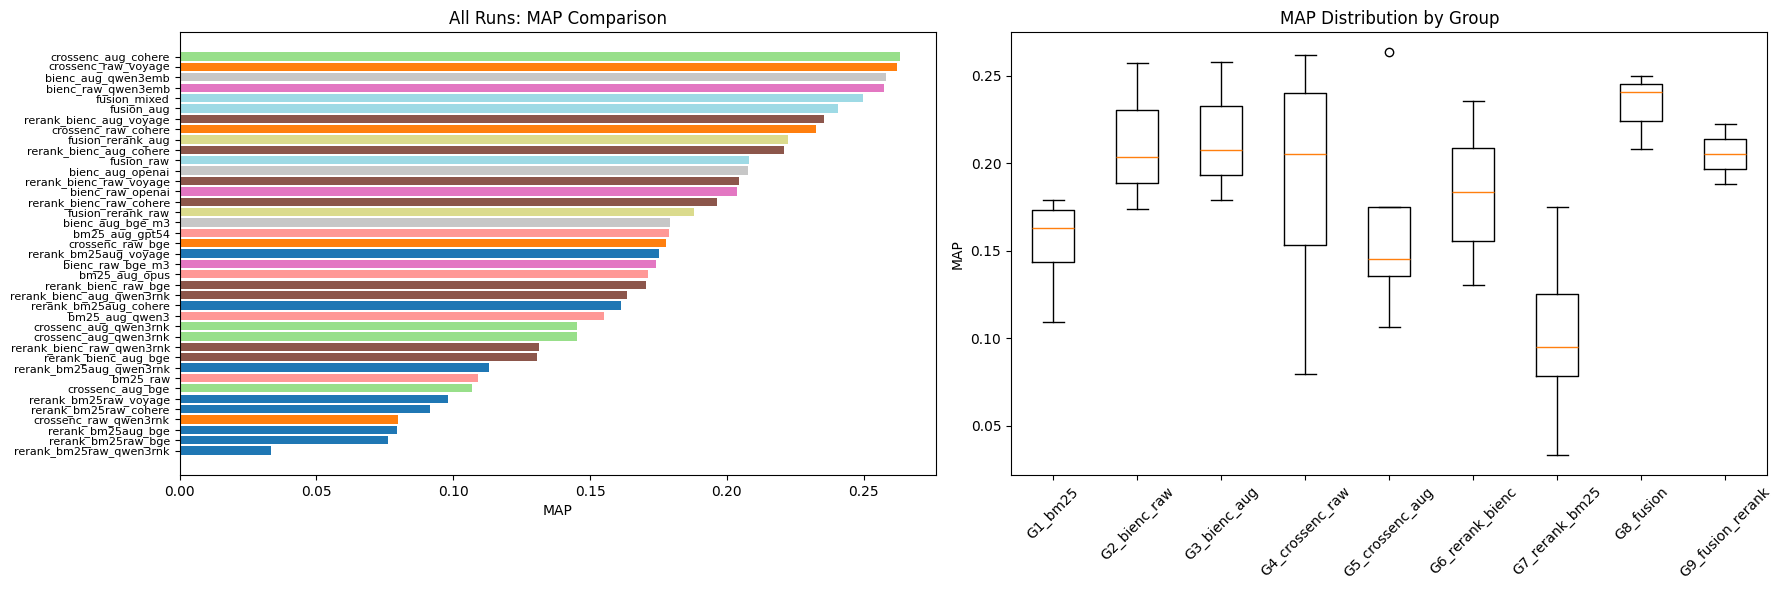

In [43]:
# ============================================================
# Visualization: MAP comparison across groups
# ============================================================
if ALL_RESULTS and len(ALL_RESULTS) > 1:
    results_df = pd.DataFrame(ALL_RESULTS)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sorted_df = results_df.sort_values("MAP", ascending=True)
    colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_df["group"].unique())))
    group_colors = {g: colors[i] for i, g in enumerate(sorted_df["group"].unique())}

    bars = axes[0].barh(range(len(sorted_df)), sorted_df["MAP"],
                         color=[group_colors[g] for g in sorted_df["group"]])
    axes[0].set_yticks(range(len(sorted_df)))
    axes[0].set_yticklabels(sorted_df["run_name"], fontsize=8)
    axes[0].set_xlabel("MAP")
    axes[0].set_title("All Runs: MAP Comparison")

    groups = results_df.groupby("group")["MAP"].apply(list).to_dict()
    group_names = list(groups.keys())
    group_values = [groups[g] for g in group_names]
    axes[1].boxplot(group_values, labels=[g.replace("group_", "G") for g in group_names], vert=True)
    axes[1].set_ylabel("MAP")
    axes[1].set_title("MAP Distribution by Group")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
# Upload to W&B as artifact
try:
    run = wandb.init(project=CONFIG["WANDB_PROJECT"], name="results_summary", reinit=True)
    artifact = wandb.Artifact("all_results", type="results")
    artifact.add_file(csv_path)
    wandb.log_artifact(artifact)
    # Also log as a W&B Table for interactive viewing
    wandb.log({"results_table": wandb.Table(dataframe=results_df[available_cols])})
    wandb.finish()
    print("Results uploaded to W&B as artifact + table")
except Exception as e:
    print(f"W&B upload failed: {e}")

#This does two things: uploads the all_results.csv as a downloadable W&B artifact,
#and logs it as a W&B Table so you can sort, filter, and compare all 39 runs interactively in the dashboard.